In [1]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("brand_analysis_dataset.csv")

In [5]:
df.head()

,user,text,likes,comments,shares,timestamp
0,user1,adidas has good style,31,3,4,2024-02-9
1,user5,I love my new nike shoes!,51,18,8,2024-02-8
2,user3,adidas has good style,73,10,10,2024-02-3
3,user4,samsung is innovative,34,20,8,2024-02-4
4,user1,apple ecosystem is smooth,41,18,3,2024-02-8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user       60 non-null     object
 1   text       60 non-null     object
 2   likes      60 non-null     int64 
 3   comments   60 non-null     int64 
 4   shares     60 non-null     int64 
 5   timestamp  60 non-null     object
dtypes: int64(3), object(3)
memory usage: 2.9+ KB


In [7]:
df.isnull().sum()

user         0
text         0
likes        0
comments     0
shares       0
timestamp    0
dtype: int64

In [8]:
brand="apple"

In [11]:
brand_df=df[df['text'].str.contains(brand)]

In [12]:
from textblob import TextBlob
brand_df['polarity']=brand_df['text'].apply(lambda x:TextBlob(str(x)).sentiment.polarity)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21760\44359868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['polarity']=brand_df['text'].apply(lambda x:TextBlob(str(x)).sentiment.polarity)


In [13]:
def get_sentiment(score):
    if score<0:
        return "Negative"
    elif score>0:
        return "Positive"
    else:
        return "Neutral"

In [14]:
brand_df['sentiment']=brand_df['polarity'].apply(get_sentiment)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21760\3416344677.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['sentiment']=brand_df['polarity'].apply(get_sentiment)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
brand_df.head()

,user,text,likes,comments,shares,timestamp,polarity,sentiment
4,user1,apple ecosystem is smooth,41,18,3,2024-02-8,0.4,Positive
5,user1,apple products are too expensive,8,12,6,2024-02-9,-0.5,Negative
7,user1,apple products are too expensive,12,0,8,2024-02-6,-0.5,Negative
14,user4,apple products are too expensive,60,12,7,2024-02-11,-0.5,Negative
20,user3,apple ecosystem is smooth,21,14,0,2024-02-3,0.4,Positive


In [23]:
brand_df['engagement']=brand_df['likes']+brand_df['comments']+brand_df['shares']

C:\Users\Admin\AppData\Local\Temp\ipykernel_21760\3453544.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['engagement']=brand_df['likes']+brand_df['comments']+brand_df['shares']


<Axes: xlabel='sentiment'>

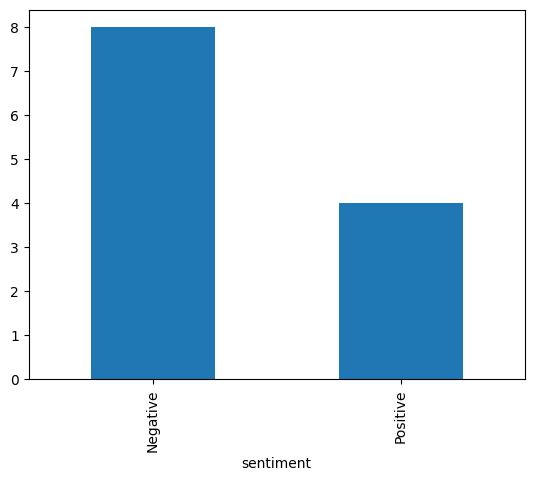

In [20]:
brand_df['sentiment'].value_counts().plot(kind='bar')

C:\Users\Admin\AppData\Local\Temp\ipykernel_21760\3301747181.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['words'] = brand_df['text'].apply(


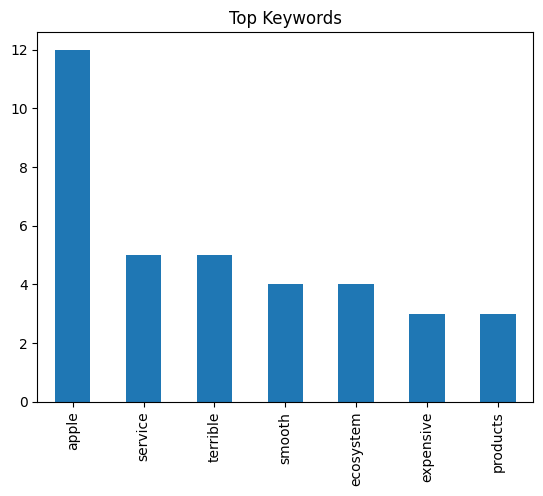

In [21]:
from gensim.parsing.preprocessing import STOPWORDS

brand_df['words'] = brand_df['text'].apply(
    lambda x: [word for word in x.split() if word not in STOPWORDS]
)

all_words = [word for words in brand_df['words'] for word in words]

word_counts = pd.Series(all_words).value_counts()

word_counts.head(10).plot(kind='bar')
plt.title("Top Keywords")
plt.show()

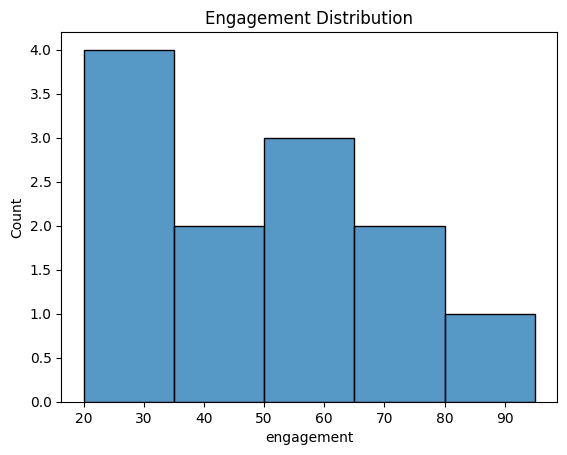

In [24]:
import seaborn as sns

sns.histplot(brand_df['engagement'])
plt.title("Engagement Distribution")
plt.show()

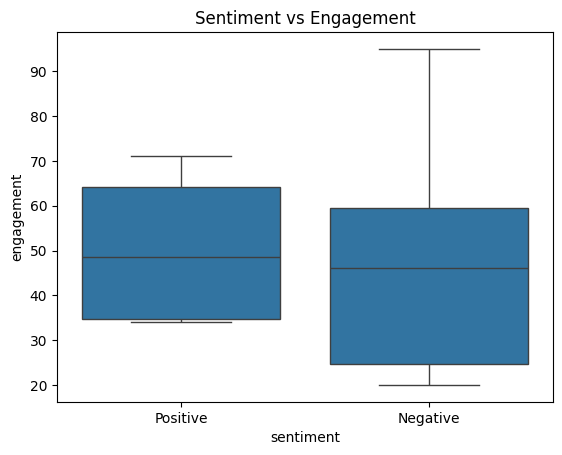

In [25]:
sns.boxplot(x=brand_df['sentiment'], y=brand_df['engagement'])
plt.title("Sentiment vs Engagement")
plt.show()